In [2]:
#Data Analysis and Visualisation on Diwali Sales Database.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset
df = pd.read_csv('Diwali_Sales_Data.csv', encoding='unicode_escape')

In [5]:
# Display first rows
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [8]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

In [11]:
# Drop unnecessary columns

df = df.drop(['Status', 'unnamed1'], axis=1, errors='ignore')


In [12]:
# Handle missing values
df.dropna(inplace=True)

In [13]:
# Convert data types
df['Amount'] = df['Amount'].astype(int)

In [14]:
df.groupby('Gender')['Amount'].sum()

,Amount
Gender,
F,74335853
M,31913276


In [15]:
df.groupby('Age Group')['Amount'].sum()

,Amount
Age Group,
0-17,2699653
18-25,17240732
26-35,42613442
36-45,22144994
46-50,9207844
51-55,8261477
55+,4080987


In [16]:
df.groupby('State')['Amount'].sum().sort_values(ascending=False)

,Amount
State,
Uttar Pradesh,19374968
Maharashtra,14427543
Karnataka,13523540
Delhi,11603818
Madhya Pradesh,8101142
Andhra Pradesh,8037146
Himachal Pradesh,4963368
Haryana,4220175
Bihar,4022757


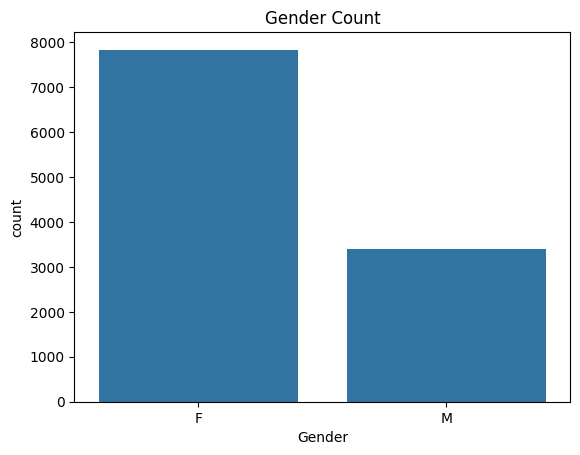

In [17]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Count")
plt.show()

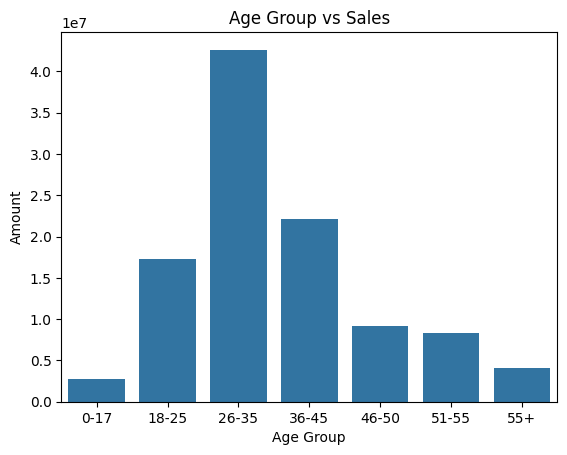

In [18]:
sales_age = df.groupby('Age Group')['Amount'].sum().reset_index()

sns.barplot(x='Age Group', y='Amount', data=sales_age)
plt.title("Age Group vs Sales")
plt.show()

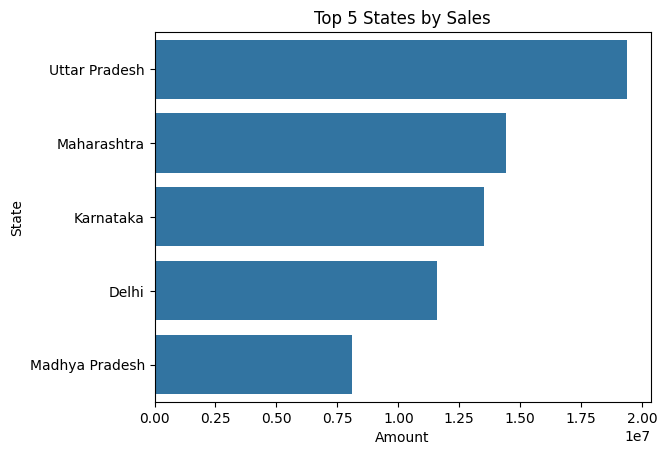

In [19]:
top_states = df.groupby('State')['Amount'].sum().nlargest(5).reset_index()

sns.barplot(x='Amount', y='State', data=top_states)
plt.title("Top 5 States by Sales")
plt.show()

In [20]:
df.to_csv("cleaned_diwali_data.csv", index=False)